In [2]:
import pandas as pd

In [3]:
import numpy as np

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
"""
problem statement of project

Forest fires can cause major damage to forests, wildlife, people, and property. Weather conditions such as high temperature, low humidity, strong wind, low rainfall, and dry vegetation can increase fire risk.
The problem is to build a machine-learning model that uses weather and environmental data to predict whether the forest condition is:
- Fire
- Not Fire
This can help authorities identify risky conditions early and take preventive action.


"""

'\nproblem statement of project\n\nForest fires can cause major damage to forests, wildlife, people, and property. Weather conditions such as high temperature, low humidity, strong wind, low rainfall, and dry vegetation can increase fire risk.\nThe problem is to build a machine-learning model that uses weather and environmental data to predict whether the forest condition is:\n- Fire\n- Not Fire\nThis can help authorities identify risky conditions early and take preventive action.\n\n\n'

## Load Dataset

In [6]:
df = pd.read_csv("The extended Algerian forest fires dataset.csv")

df.head()

,DATE,Temperature,Ws,Rain,RH,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Bejaia 2021
0,06/01/2021,27,13,2.1,59,63.6,5.2,8.3,1.0,5.0,0.4,not fire,Bejaia 2021
1,06/02/2021,24,10,0.3,72,55.1,4.1,7.7,0.5,4.0,0.2,not fire,Bejaia 2021
2,06/03/2021,27,11,3.0,76,47.1,3.0,8.3,0.2,3.2,0.1,not fire,Bejaia 2021
3,06/04/2021,28,9,1.0,70,52.3,3.1,8.4,0.3,3.2,0.1,not fire,Bejaia 2021
4,06/05/2021,28,11,0.1,64,73.4,4.5,16.9,1.6,5.4,0.7,not fire,Bejaia 2021


## check shape and size of dataset

In [7]:
#check shape and size of dataset
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Dataset shape: (1215, 13)

Column names:
['DATE', 'Temperature', '        Ws', '    Rain', 'RH', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Bejaia 2021']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1215 entries, 0 to 1214
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE         1215 non-null   object 
 1   Temperature  1215 non-null   int64  
 2           Ws   1215 non-null   int64  
 3       Rain     1215 non-null   float64
 4   RH           1215 non-null   int64  
 5   FFMC         1215 non-null   float64
 6   DMC          1215 non-null   float64
 7   DC           1215 non-null   float64
 8   ISI          1215 non-null   float64
 9   BUI          1215 non-null   float64
 10  FWI          1215 non-null   float64
 11  Classes      1215 non-null   object 
 12  Bejaia 2021  1215 non-null   object 
dtypes: float64(7), int64(3), object(3)
memory usage: 123.5+ KB


In [8]:
# check missing values
# Clean spaces in column names
df.columns = df.columns.str.strip()

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()
df.isnull().sum()

Dataset shape: (1215, 13)

Columns:
['DATE', 'Temperature', 'Ws', 'Rain', 'RH', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Bejaia 2021']


DATE           0
Temperature    0
Ws             0
Rain           0
RH             0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Bejaia 2021    0
dtype: int64

In [9]:
#view final 5 rows of dataset
df.tail()

,DATE,Temperature,Ws,Rain,RH,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Bejaia 2021
1210,09/26/2021,32,10,0.0,83,84.8,12.4,34.5,3.4,13.1,4.2,not fire,Tizi-Ouzou2021
1211,09/27/2021,30,12,0.0,96,78.8,12.6,41.6,1.8,14.4,2.1,not fire,Tizi-Ouzou2021
1212,09/28/2021,30,12,0.0,69,84.4,14.3,48.7,3.5,16.5,5.1,not fire,Tizi-Ouzou2021
1213,09/29/2021,31,14,0.0,72,85.1,15.9,56.0,4.3,18.6,6.7,not fire,Tizi-Ouzou2021
1214,09/30/2021,28,12,0.0,81,84.4,16.9,62.8,3.5,20.2,5.8,not fire,Tizi-Ouzou2021


In [10]:
print(df.columns.tolist())

['DATE', 'Temperature', 'Ws', 'Rain', 'RH', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Bejaia 2021']


In [11]:
df_clean = df.copy()

df_clean = df_clean.rename(columns={
    "Bejaia 2021": "Region"
})

print(df_clean.columns.tolist())

['DATE', 'Temperature', 'Ws', 'Rain', 'RH', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region']


## Clean text columns

In [12]:
# Clean fire/not-fire labels
df_clean["Classes"] = (
    df_clean["Classes"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
)

# Remove the year attached to region names, e.g. Tizi-Ouzou2021 → Tizi-Ouzou
df_clean["Region"] = (
    df_clean["Region"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s*\d{4}$", "", regex=True)
)

print("Fire class labels:")
print(df_clean["Classes"].value_counts())

print("\nRegions:")
print(df_clean["Region"].value_counts())

Fire class labels:
Classes
fire        633
not fire    582
Name: count, dtype: int64

Regions:
Region
Bejaia            122
Blida             122
Bouira            122
Tipaza            122
Setif             122
Tiaret            122
Bejaia_           122
Sidi-Bel-Abass    122
Tizi-Ouzou        122
Khenchela         117
Name: count, dtype: int64


## Convert date and create useful date columns

In [13]:
df_clean["DATE"] = pd.to_datetime(
    df_clean["DATE"],
    errors="coerce"
)

df_clean["Year"] = df_clean["DATE"].dt.year
df_clean["Month"] = df_clean["DATE"].dt.month
df_clean["Day"] = df_clean["DATE"].dt.day

df_clean[["DATE", "Year", "Month", "Day"]].head()

,DATE,Year,Month,Day
0,2021-06-01,2021.0,6.0,1.0
1,2021-06-02,2021.0,6.0,2.0
2,2021-06-03,2021.0,6.0,3.0
3,2021-06-04,2021.0,6.0,4.0
4,2021-06-05,2021.0,6.0,5.0


## Convert weather and fire-index columns to numeric values

In [14]:
numeric_columns = [
    "Temperature", "Ws", "Rain", "RH",
    "FFMC", "DMC", "DC", "ISI", "BUI", "FWI"
]

for col in numeric_columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1215 entries, 0 to 1214
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   DATE         1214 non-null   datetime64[ns]
 1   Temperature  1215 non-null   int64         
 2   Ws           1215 non-null   int64         
 3   Rain         1215 non-null   float64       
 4   RH           1215 non-null   int64         
 5   FFMC         1215 non-null   float64       
 6   DMC          1215 non-null   float64       
 7   DC           1215 non-null   float64       
 8   ISI          1215 non-null   float64       
 9   BUI          1215 non-null   float64       
 10  FWI          1215 non-null   float64       
 11  Classes      1215 non-null   object        
 12  Region       1215 non-null   object        
 13  Year         1214 non-null   float64       
 14  Month        1214 non-null   float64       
 15  Day          1214 non-null   float64       
dtypes: dat

## Check missing values and remove incomplete rows

In [15]:
print("Missing values before cleaning:")
print(df_clean.isnull().sum())

df_clean = df_clean.dropna().copy()

print("\nDataset shape after cleaning:", df_clean.shape)

print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

Missing values before cleaning:
DATE           1
Temperature    0
Ws             0
Rain           0
RH             0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
Year           1
Month          1
Day            1
dtype: int64

Dataset shape after cleaning: (1214, 16)

Missing values after cleaning:
DATE           0
Temperature    0
Ws             0
Rain           0
RH             0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
Year           0
Month          0
Day            0
dtype: int64


## Convert the output label to numbers

In [16]:
df_clean["Fire"] = df_clean["Classes"].map({
    "not fire": 0,
    "fire": 1
})

print(df_clean[["Classes", "Fire"]].head())

print("\nTarget distribution:")
print(df_clean["Fire"].value_counts())

    Classes  Fire
0  not fire     0
1  not fire     0
2  not fire     0
3  not fire     0
4  not fire     0

Target distribution:
Fire
1    632
0    582
Name: count, dtype: int64


## Show Fire vs Not Fire count chart

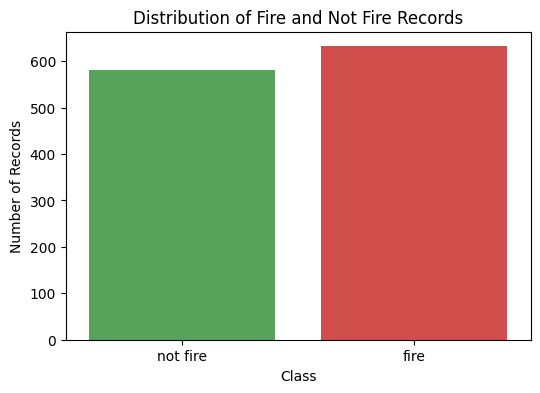

In [17]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_clean,
    x="Classes",
    hue="Classes",
    palette=["#4CAF50", "#E53935"],
    legend=False
)

plt.title("Distribution of Fire and Not Fire Records")
plt.xlabel("Class")
plt.ylabel("Number of Records")
plt.show()

## Compare temperature for fire and not-fire cases

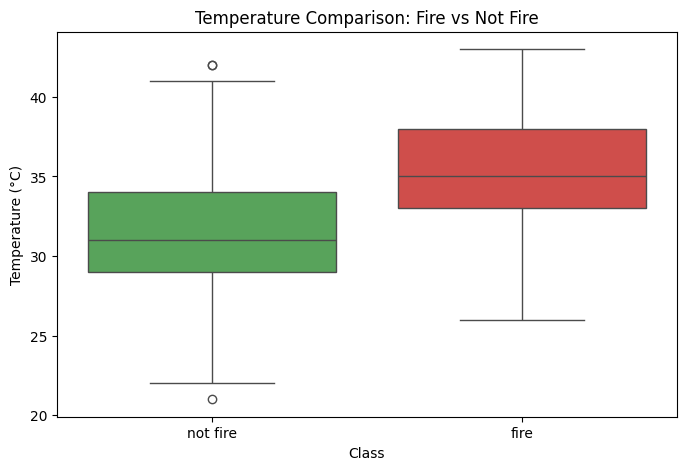

In [18]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Classes",
    y="Temperature",
    hue="Classes",
    palette=["#4CAF50", "#E53935"],
    legend=False
)

plt.title("Temperature Comparison: Fire vs Not Fire")
plt.xlabel("Class")
plt.ylabel("Temperature (°C)")
plt.show()

## Compare humidity for fire and not-fire cases

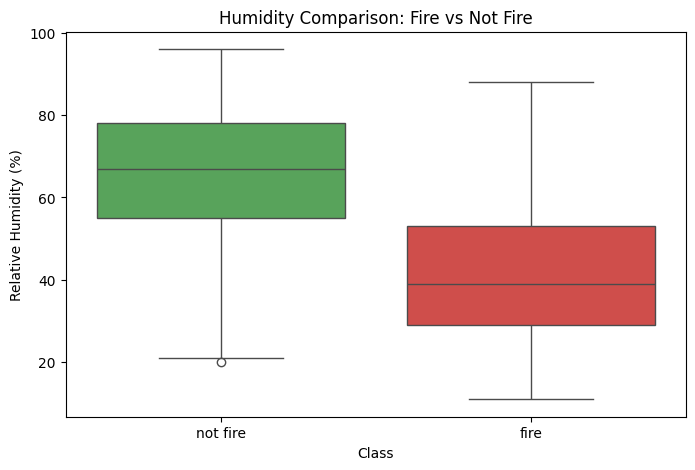

In [19]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Classes",
    y="RH",
    hue="Classes",
    palette=["#4CAF50", "#E53935"],
    legend=False
)

plt.title("Humidity Comparison: Fire vs Not Fire")
plt.xlabel("Class")
plt.ylabel("Relative Humidity (%)")
plt.show()

## Correlation heatmap

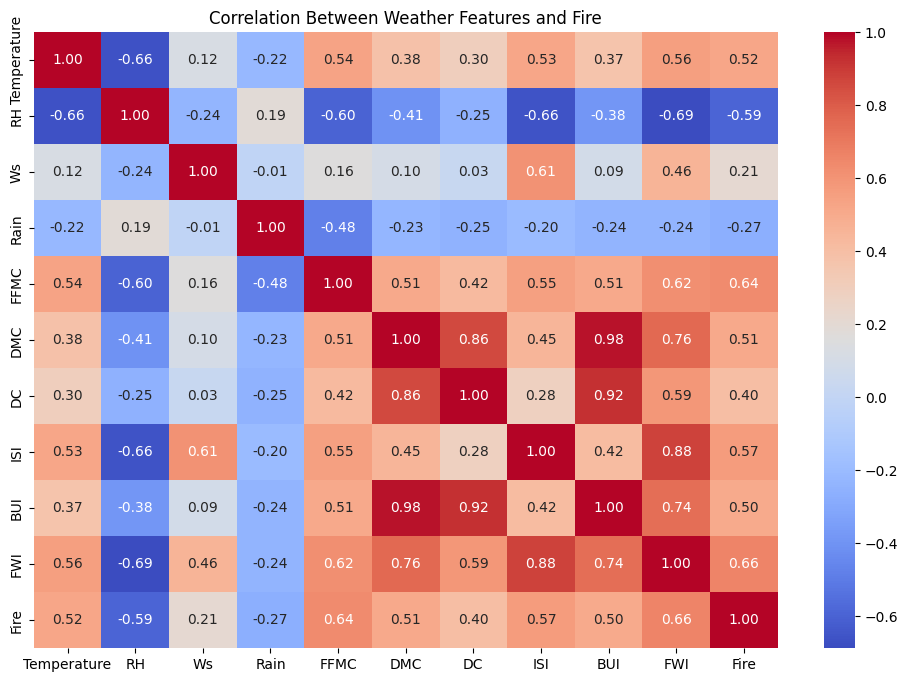

In [20]:
plt.figure(figsize=(12, 8))

correlation = df_clean[
    ["Temperature", "RH", "Ws", "Rain", "FFMC", "DMC",
     "DC", "ISI", "BUI", "FWI", "Fire"]
].corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Between Weather Features and Fire")
plt.show()
#This chart helps identify which features have the strongest relationship with fire risk

In [21]:
## Save Cleaned Dataset
df_clean.to_csv("extended_algerian_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


## Select input features and target

In [22]:
features = [
    "Temperature",
    "RH",
    "Ws",
    "Rain",
    "FFMC",
    "DMC",
    "ISI"
]

X = df_clean[features]
y = df_clean["Fire"].astype(int)

print("Input feature shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())

Input feature shape: (1214, 7)
Target shape: (1214,)


,Temperature,RH,Ws,Rain,FFMC,DMC,ISI
0,27,59,13,2.1,63.6,5.2,1.0
1,24,72,10,0.3,55.1,4.1,0.5
2,27,76,11,3.0,47.1,3.0,0.2
3,28,70,9,1.0,52.3,3.1,0.3
4,28,64,11,0.1,73.4,4.5,1.6


## Split data into training and testing data

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data shape: (971, 7)
Testing data shape: (243, 7)

Training target distribution:
Fire
1    505
0    466
Name: count, dtype: int64

Testing target distribution:
Fire
1    127
0    116
Name: count, dtype: int64


## Scale the feature values

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data scaling completed.")

#Scaling makes columns with different ranges—for example rainfall versus temperature—comparable

Data scaling completed.


## Train three machine-learning models

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

## Train all three models

In [26]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42
    )
}

results = []
trained_models = {}

for name, model in models.items():
    # Train model using training data
    model.fit(X_train_scaled, y_train)

    # Predict fire / not fire for unseen test data
    y_pred = model.predict(X_test_scaled)

    # Store trained model
    trained_models[name] = model

    # Calculate evaluation metrics
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.868313,0.857143,0.897638,0.876923
1,Decision Tree,0.872428,0.893443,0.858268,0.875502
2,Random Forest,0.909465,0.926829,0.897638,0.912000


## Show the best model

In [27]:
results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.909465,0.926829,0.897638,0.912000
0,Logistic Regression,0.868313,0.857143,0.897638,0.876923
1,Decision Tree,0.872428,0.893443,0.858268,0.875502


## Evaluate the selected Random Forest model

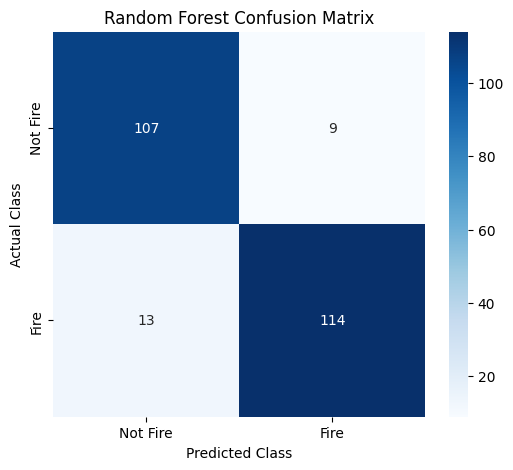

In [28]:
#Create the confusion matrix
best_model = trained_models["Random Forest"]

y_pred_rf = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Fire", "Fire"],
    yticklabels=["Not Fire", "Fire"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

In [29]:
best_model = trained_models["Random Forest"]

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": best_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

display(importance_df)

,Feature,Importance
4,FFMC,0.320156
6,ISI,0.296005
5,DMC,0.117115
1,RH,0.107398
0,Temperature,0.066179
3,Rain,0.054619
2,Ws,0.038527


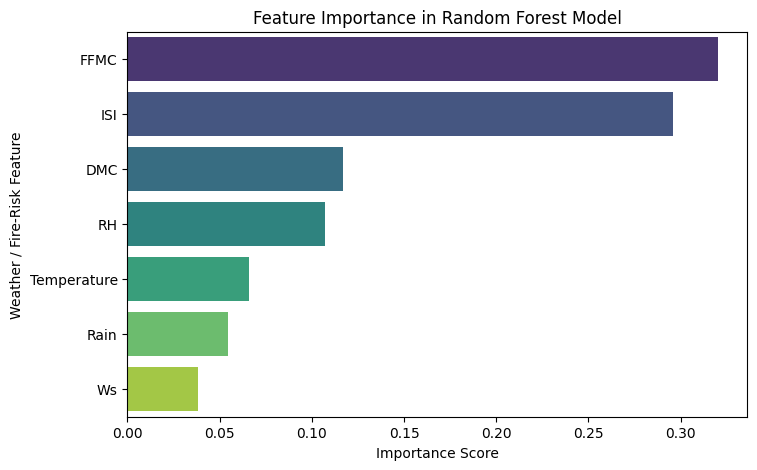

In [30]:
#Show feature importance
plt.figure(figsize=(8, 5))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Feature Importance in Random Forest Model")
plt.xlabel("Importance Score")
plt.ylabel("Weather / Fire-Risk Feature")
plt.show()

## Test with one real test-data record

In [31]:
# Select one record that the model never saw during training
sample_index = X_test.index[0]

sample_input = X_test.loc[[sample_index]]
actual_result = y_test.loc[sample_index]

# Scale the input exactly as during training
sample_input_scaled = scaler.transform(sample_input)

# Predict class and fire probability
prediction = best_model.predict(sample_input_scaled)[0]
probability = best_model.predict_proba(sample_input_scaled)[0][1]

print("Input weather values:")
display(sample_input)

print("Actual class:", "Fire" if actual_result == 1 else "Not Fire")
print("Predicted class:", "Fire" if prediction == 1 else "Not Fire")
print(f"Fire probability: {probability:.2%}")

Input weather values:


,Temperature,RH,Ws,Rain,FFMC,DMC,ISI
499,32,58,15,0.1,82.9,35.2,6.3


Actual class: Not Fire
Predicted class: Not Fire
Fire probability: 22.36%


## reusable prediction function

In [32]:
def predict_fire_risk(temperature, humidity, wind_speed, rain, ffmc, dmc, isi):
    
    new_data = pd.DataFrame([{
        "Temperature": temperature,
        "RH": humidity,
        "Ws": wind_speed,
        "Rain": rain,
        "FFMC": ffmc,
        "DMC": dmc,
        "ISI": isi
    }])

    new_data_scaled = scaler.transform(new_data)

    prediction = best_model.predict(new_data_scaled)[0]
    probability = best_model.predict_proba(new_data_scaled)[0][1]

    if prediction == 1:
        result = "High Fire Risk"
    else:
        result = "Low Fire Risk"

    return result, probability

In [33]:
result, probability = predict_fire_risk(
    temperature=32,
    humidity=35,
    wind_speed=18,
    rain=0.0,
    ffmc=88.0,
    dmc=25.0,
    isi=8.0
)

print("Prediction:", result)
print(f"Fire probability: {probability:.2%}")

Prediction: High Fire Risk
Fire probability: 59.52%


In [34]:
import joblib

joblib.dump(
    {
        "model": best_model,
        "scaler": scaler,
        "features": features
    },
    "forest_fire_random_forest_model.pkl"
)

['forest_fire_random_forest_model.pkl']

In [35]:
import sys

!{sys.executable} -m pip install ipywidgets


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: C:\Users\hp\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [36]:
import ipywidgets as widgets

from IPython.display import display, HTML, clear_output

## Create input boxes

In [37]:
style = {"description_width": "initial"}
box_layout = widgets.Layout(width="330px")

temperature_input = widgets.BoundedFloatText(
    value=32.0,
    min=0,
    max=60,
    step=0.1,
    description="Temperature (°C):",
    style=style,
    layout=box_layout
)

humidity_input = widgets.BoundedFloatText(
    value=35.0,
    min=0,
    max=100,
    step=0.1,
    description="Relative Humidity (%):",
    style=style,
    layout=box_layout
)

wind_input = widgets.BoundedFloatText(
    value=18.0,
    min=0,
    max=100,
    step=0.1,
    description="Wind Speed (km/h):",
    style=style,
    layout=box_layout
)

rain_input = widgets.BoundedFloatText(
    value=0.0,
    min=0,
    max=100,
    step=0.1,
    description="Rainfall (mm):",
    style=style,
    layout=box_layout
)

ffmc_input = widgets.BoundedFloatText(
    value=88.0,
    min=0,
    max=101,
    step=0.1,
    description="FFMC:",
    style=style,
    layout=box_layout
)

dmc_input = widgets.BoundedFloatText(
    value=25.0,
    min=0,
    max=200,
    step=0.1,
    description="DMC:",
    style=style,
    layout=box_layout
)

isi_input = widgets.BoundedFloatText(
    value=8.0,
    min=0,
    max=100,
    step=0.1,
    description="ISI:",
    style=style,
    layout=box_layout
)

In [38]:
predict_button = widgets.Button(
    description="Predict Fire Risk",
    button_style="danger",
    icon="fire",
    layout=widgets.Layout(width="200px", height="40px")
)

result_output = widgets.Output()

def predict_from_form(button):
    
    input_data = pd.DataFrame([{
        "Temperature": temperature_input.value,
        "RH": humidity_input.value,
        "Ws": wind_input.value,
        "Rain": rain_input.value,
        "FFMC": ffmc_input.value,
        "DMC": dmc_input.value,
        "ISI": isi_input.value
    }])

    # Ensure feature order exactly matches training
    input_data = input_data[features]

    input_scaled = scaler.transform(input_data)

    prediction = best_model.predict(input_scaled)[0]
    probability = best_model.predict_proba(input_scaled)[0][1]

    with result_output:
        clear_output()

        if prediction == 1:
            display(HTML(
                f"<h3 style='color:#d32f2f;'>🔥 High Fire Risk</h3>"
                f"<h4>Estimated probability of fire: {probability:.1%}</h4>"
            ))
        else:
            display(HTML(
                f"<h3 style='color:#2e7d32;'>✅ Low Fire Risk</h3>"
                f"<h4>Estimated probability of fire: {probability:.1%}</h4>"
            ))

predict_button.on_click(predict_from_form)

##Display mini-project interface

In [39]:
title = widgets.HTML(
    "<h2>🔥 Forest Fire Risk Prediction</h2>"
    "<p>Enter weather and fire-weather values, then click Predict.</p>"
)

form = widgets.VBox([
    title,
    temperature_input,
    humidity_input,
    wind_input,
    rain_input,
    ffmc_input,
    dmc_input,
    isi_input,
    predict_button,
    result_output
])

display(form)